In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

In [2]:
kanser_verisi = load_breast_cancer()
df = pd.DataFrame(kanser_verisi.data, columns=kanser_verisi.feature_names)
df['Hedef'] = kanser_verisi.target

X = df.drop('Hedef', axis=1)
y = df['Hedef']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_olcekli = scaler.fit_transform(X_train)
X_test_olcekli = scaler.transform(X_test)

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_olcekli, y_train)

tahminler_svm = svm_model.predict(X_test_olcekli)
basari_svm = accuracy_score(y_test, tahminler_svm)

print(f"SVM (Lineer Kernel) Doğruluk Oranı: %{basari_svm * 100:.2f}")

SVM (Lineer Kernel) Doğruluk Oranı: %95.61


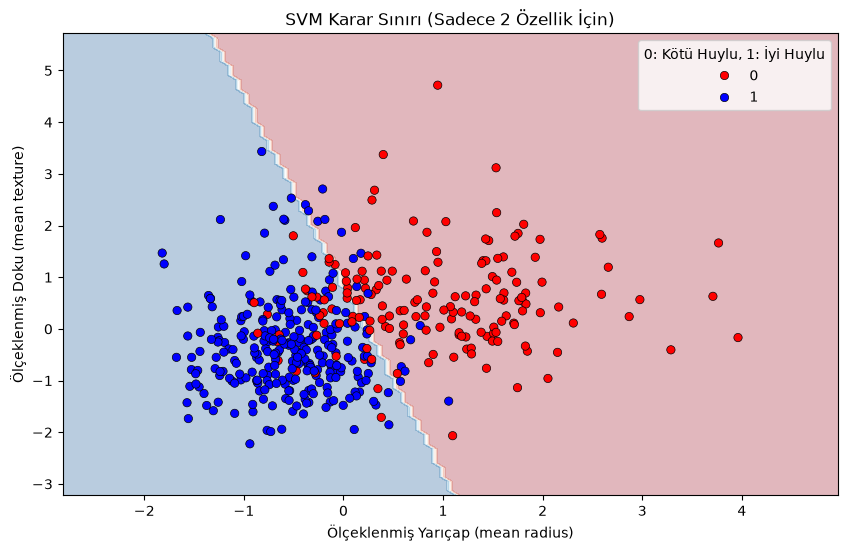

In [4]:
X_gorsel = X_train_olcekli[:, :2] 

# Sadece bu 2 boyutlu veriyle mini bir SVM modeli eğitiyoruz
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X_gorsel, y_train)

fig, ax = plt.subplots(figsize=(10, 6))

# SVM'in karar sınırını (otobanı) arka plan renkleriyle çizdiriyoruz
DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_gorsel,
    response_method="predict",
    cmap="RdBu", # Kırmızı (0) ve Mavi (1) bölgeler
    alpha=0.3,
    ax=ax
)

# Gerçek veri noktalarını (hücreleri) grafiğe serpiştiriyoruz
sns.scatterplot(
    x=X_gorsel[:, 0], 
    y=X_gorsel[:, 1], 
    hue=y_train, 
    palette=['red', 'blue'],
    edgecolor="k",
    ax=ax
)

plt.title('SVM Karar Sınırı (Sadece 2 Özellik İçin)')
plt.xlabel('Ölçeklenmiş Yarıçap (mean radius)')
plt.ylabel('Ölçeklenmiş Doku (mean texture)')
plt.legend(title='0: Kötü Huylu, 1: İyi Huylu', loc='upper right')
plt.show()